In [1]:
print('Hello World')

Hello World


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import LatentDirichletAllocation

In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>
[nltk_data] Error loading wordnet: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>
[nltk_data] Error loading omw-1.4: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:992)>


False

In [5]:
df = pd.read_csv('TestReviews.csv')

df.head(10)

,review,class
0,Fantastic spot for an even or a quite cocktail...,1
1,"Love, love, love the calamari. It's so good an...",1
2,"Love this place. Stiff martinis and cocktails,...",1
3,It's everything a great cocktail bar should be...,1
4,"I came here before a pirates game, so it was a...",1
5,Olive or Twist is the historic site of my VERY...,1
6,"A beautiful little bar with an exciting ""marti...",1
7,My favorite bar in town love the live music an...,1
8,"The location is in a strip mall, but this plac...",1
9,THIS PLACE IS OPEN!The best food and the best ...,1


In [ ]:
df = df.rename(columns={'review': 'review_text', 'class': 'sentiment'})
df['sentiment_label'] = df['sentiment'].map({1: 'Positive', 0: 'Negative'})

df.head(10)

,review_text,sentiment,sentiment_label
0,Fantastic spot for an even or a quite cocktail...,1,Positive
1,"Love, love, love the calamari. It's so good an...",1,Positive
2,"Love this place. Stiff martinis and cocktails,...",1,Positive
3,It's everything a great cocktail bar should be...,1,Positive
4,"I came here before a pirates game, so it was a...",1,Positive
5,Olive or Twist is the historic site of my VERY...,1,Positive
6,"A beautiful little bar with an exciting ""marti...",1,Positive
7,My favorite bar in town love the live music an...,1,Positive
8,"The location is in a strip mall, but this plac...",1,Positive
9,THIS PLACE IS OPEN!The best food and the best ...,1,Positive


In [7]:
df['character_count'] = df['review_text'].astype(str).apply(len)
df['word_count'] = df['review_text'].astype(str).apply(lambda x: len(x.split()))

df[['review_text', 'sentiment_label', 'character_count', 'word_count']].head()

,review_text,sentiment_label,character_count,word_count
0,Fantastic spot for an even or a quite cocktail...,Positive,227,40
1,"Love, love, love the calamari. It's so good an...",Positive,286,56
2,"Love this place. Stiff martinis and cocktails,...",Positive,359,61
3,It's everything a great cocktail bar should be...,Positive,352,60
4,"I came here before a pirates game, so it was a...",Positive,771,147


In [9]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    
    tokens = text.split()
    clean_tokens = []
    for word in tokens:
        if word not in stop_words:
            lemma = lemmatizer.lemmatize(word)
            clean_tokens.append(lemma)
    
    return ' '.join(clean_tokens)

In [10]:
df['clean_review'] = df['review_text'].apply(preprocess_text)

df[['review_text', 'clean_review', 'sentiment_label']].head(10)

,review_text,clean_review,sentiment_label
0,Fantastic spot for an even or a quite cocktail...,fantastic spot even quite cocktail swell host ...,Positive
1,"Love, love, love the calamari. It's so good an...",love love love calamari good spicy endless lis...,Positive
2,"Love this place. Stiff martinis and cocktails,...",love place stiff martini cocktail cheap drink ...,Positive
3,It's everything a great cocktail bar should be...,everything great cocktail bar great location a...,Positive
4,"I came here before a pirates game, so it was a...",came pirate game around ish evening gotten luc...,Positive
5,Olive or Twist is the historic site of my VERY...,olive twist historic site first martini turned...,Positive
6,"A beautiful little bar with an exciting ""marti...",beautiful little bar exciting martini list ste...,Positive
7,My favorite bar in town love the live music an...,favorite bar town love live music martini fave...,Positive
8,"The location is in a strip mall, but this plac...",location strip mall place diamond rough food b...,Positive
9,THIS PLACE IS OPEN!The best food and the best ...,place open best food best service try butter n...,Positive


In [11]:
print('Original Review:')
print(df.loc[0, 'review_text'])

print('Cleaned Review:')
print(df.loc[0, 'clean_review'])

Original Review:
Fantastic spot for an even or a quite cocktail.  They were swell to host the Yelp crew with a great drink menu and super attentive staff.I'd certainly recommend anything with the purred fruit in it (apple, any of them really)!

Cleaned Review:
fantastic spot even quite cocktail swell host yelp crew great drink menu super attentive staff certainly recommend anything purred fruit apple really


/var/folders/k8/kc8jrng519q81_pvhp9qvnyr0000gn/T/ipykernel_1121/2370497716.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')


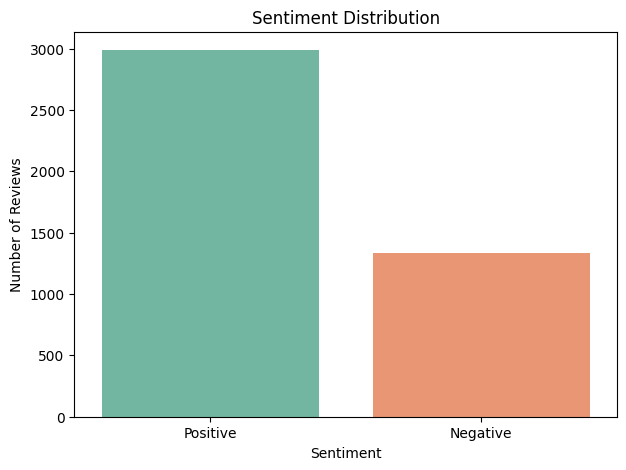

In [13]:
sentiment_counts = df['sentiment_label'].value_counts()

plt.figure(figsize=(7, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values, palette='Set2')
plt.title('Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

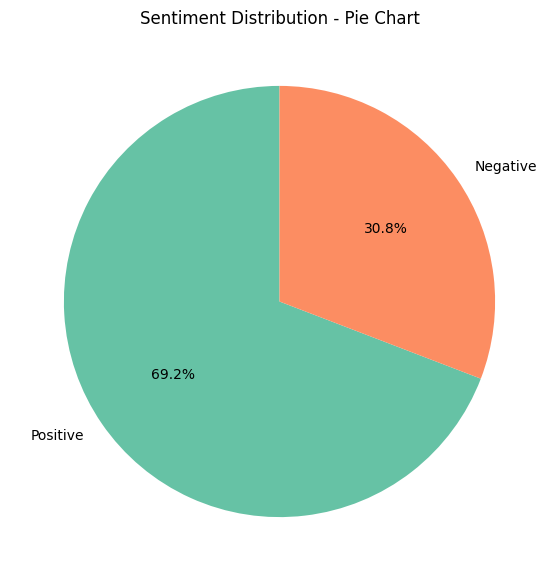

In [19]:
plt.figure(figsize=(7, 7))
plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=['#66c2a5', '#fc8d62']
)
plt.title('Sentiment Distribution - Pie Chart')
plt.show()

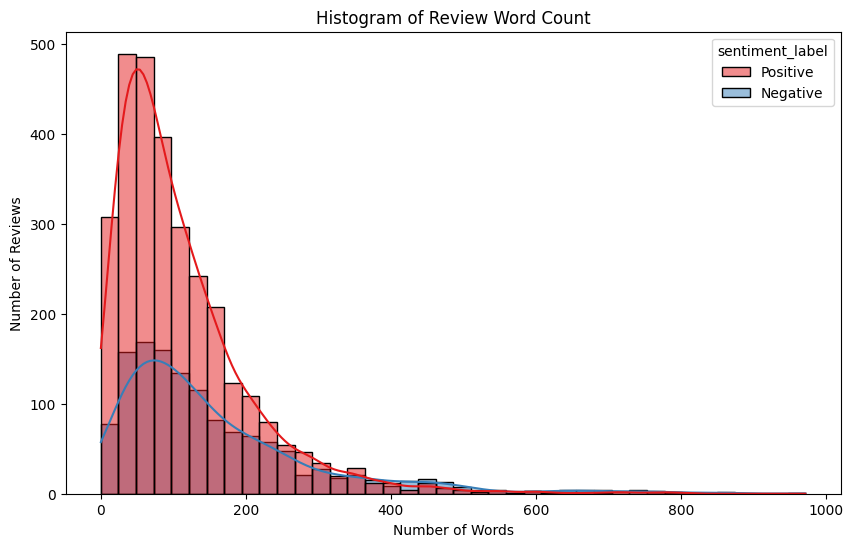

In [20]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='word_count', hue='sentiment_label', bins=40, kde=True, palette='Set1')
plt.title('Histogram of Review Word Count')
plt.xlabel('Number of Words')
plt.ylabel('Number of Reviews')
plt.show()

In [25]:
bow_vectorizer = CountVectorizer(max_features=3000)
X_bow = bow_vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']
print(bow_vectorizer.get_feature_names_out()[:20])
print(X_bow.toarray())

['aaa' 'ability' 'able' 'absolute' 'absolutely' 'ac' 'accept' 'access'
 'accessible' 'accessory' 'accident' 'accidentally' 'accommodate'
 'accommodating' 'according' 'account' 'acknowledge' 'acknowledged'
 'acoustic' 'across']
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [26]:
tfidf_vectorizer = TfidfVectorizer(max_features=3000)
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_review'])

print(X_tfidf.toarray())

[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]


In [27]:
tfidf_sample = pd.DataFrame(
    X_tfidf[:5].toarray(),
    columns=tfidf_vectorizer.get_feature_names_out()
)

tfidf_sample.head(10)

,aaa,ability,able,absolute,absolutely,ac,accept,access,accessible,accessory,...,yogurt,york,young,younger,yr,yuck,yum,yummy,zero,zia
0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
1,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
2,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
3,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,...,0.0,0.245904,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0
4,0.0,0.0,0.0,0.0,0.106414,0.0,0.0,0.0,0.0,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.135567,0.0,0.0


In [ ]:
X_train_bow, X_test_bow, y_train, y_test = train_test_split(X_bow, y, test_size=0.2, random_state=42, stratify=y)

X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(X_tfidf, y, test_size=0.2, random_state=42, stratify=y)

In [29]:
nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [30]:
nb_predictions = nb_model.predict(X_test_bow)
nb_accuracy = accuracy_score(y_test, nb_predictions)

In [32]:
print('Naive Bayes Accuracy:', nb_accuracy)
print('Classification Report:')
print(classification_report(y_test, nb_predictions, target_names=['Negative', 'Positive']))

Naive Bayes Accuracy: 0.9387283236994219
Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90       267
    Positive       0.95      0.96      0.96       598

    accuracy                           0.94       865
   macro avg       0.93      0.93      0.93       865
weighted avg       0.94      0.94      0.94       865



In [33]:
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_tfidf, y_train_tfidf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [34]:
lr_predictions = lr_model.predict(X_test_tfidf)
lr_accuracy = accuracy_score(y_test_tfidf, lr_predictions)

In [35]:
print('Logistic Regression + TF-IDF Accuracy:', lr_accuracy)
print('Classification Report:')
print(classification_report(y_test_tfidf, lr_predictions, target_names=['Negative', 'Positive']))

Logistic Regression + TF-IDF Accuracy: 0.9260115606936417
Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.78      0.87       267
    Positive       0.91      0.99      0.95       598

    accuracy                           0.93       865
   macro avg       0.94      0.88      0.91       865
weighted avg       0.93      0.93      0.92       865



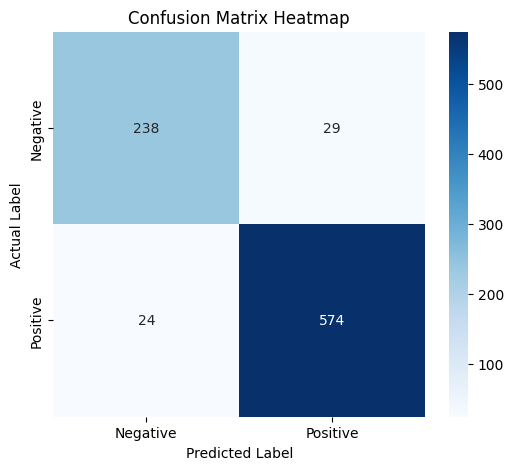

In [ ]:
cm = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

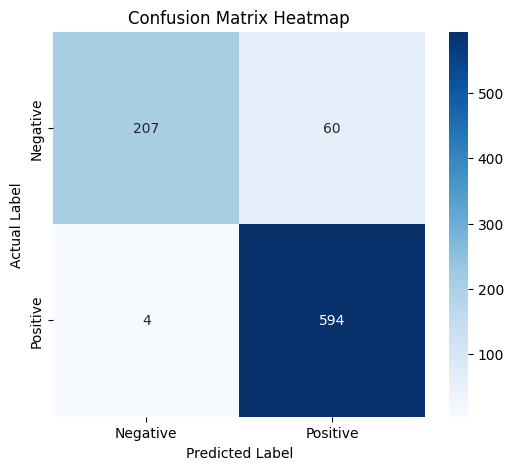

In [ ]:
cm = confusion_matrix(y_test_tfidf, lr_predictions)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative','Positive'],
    yticklabels=['Negative','Positive']
)
plt.title('Confusion Matrix Heatmap')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')
plt.show()

In [38]:
new_reviews = [
    'The food was delicious and the service was excellent.',
    'The place was dirty and the staff was very rude.',
    'Average experience, not too good and not too bad.'
]

new_reviews_clean = [preprocess_text(review) for review in new_reviews]
new_reviews_tfidf = tfidf_vectorizer.transform(new_reviews_clean)
new_predictions = lr_model.predict(new_reviews_tfidf)

for review, prediction in zip(new_reviews, new_predictions):
    label = 'Positive' if prediction == 1 else 'Negative'
    print(review, '=>', label)

The food was delicious and the service was excellent. => Positive
The place was dirty and the staff was very rude. => Negative
Average experience, not too good and not too bad. => Negative


In [39]:
topic_vectorizer = CountVectorizer(max_df=0.90, min_df=5, max_features=2000)

topic_matrix = topic_vectorizer.fit_transform(df['clean_review'])

In [ ]:
lda_model = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)

lda_model.fit(topic_matrix)

Topic matrix shape: (4321, 2000)


In [41]:
# Function to display top words from each topic

def show_topics(model, feature_names, number_of_words=10):
    for topic_number, topic in enumerate(model.components_):
        top_words_index = topic.argsort()[-number_of_words:][::-1]
        top_words = [feature_names[i] for i in top_words_index]
        print('Topic', topic_number + 1, ':', ', '.join(top_words))

feature_names = topic_vectorizer.get_feature_names_out()
show_topics(lda_model, feature_names, 10)

Topic 1 : food, place, good, like, restaurant, one, get, time, service, order
Topic 2 : place, time, like, one, show, drink, get, bar, night, go
Topic 3 : great, place, love, always, go, time, friendly, best, good, also
Topic 4 : time, staff, one, place, room, get, dr, like, day, care
Topic 5 : would, service, back, time, get, customer, said, go, told, one


In [ ]:
topic_results = lda_model.transform(topic_matrix)
df['dominant_topic'] = topic_results.argmax(axis=1) + 1

df[['review_text', 'sentiment_label', 'dominant_topic']].head()

,review_text,sentiment_label,dominant_topic
0,Fantastic spot for an even or a quite cocktail...,Positive,3
1,"Love, love, love the calamari. It's so good an...",Positive,3
2,"Love this place. Stiff martinis and cocktails,...",Positive,3
3,It's everything a great cocktail bar should be...,Positive,3
4,"I came here before a pirates game, so it was a...",Positive,1


/var/folders/k8/kc8jrng519q81_pvhp9qvnyr0000gn/T/ipykernel_1121/3133728541.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='magma')


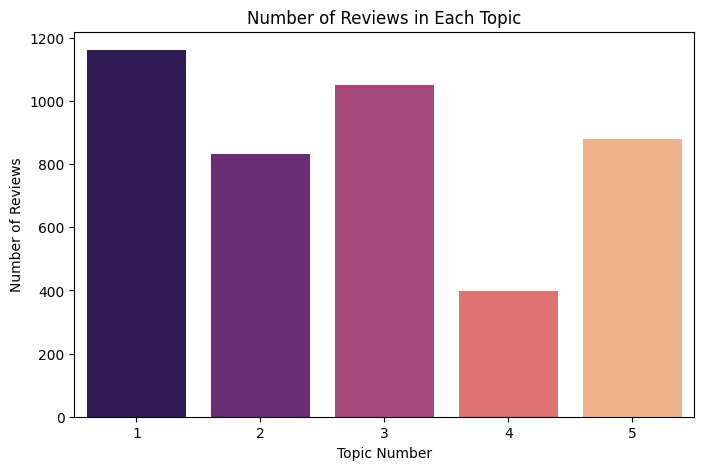

In [ ]:
topic_counts = df['dominant_topic'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
sns.barplot(x=topic_counts.index, y=topic_counts.values, palette='magma')
plt.title('Number of Reviews in Each Topic')
plt.xlabel('Topic Number')
plt.ylabel('Number of Reviews')
plt.show()

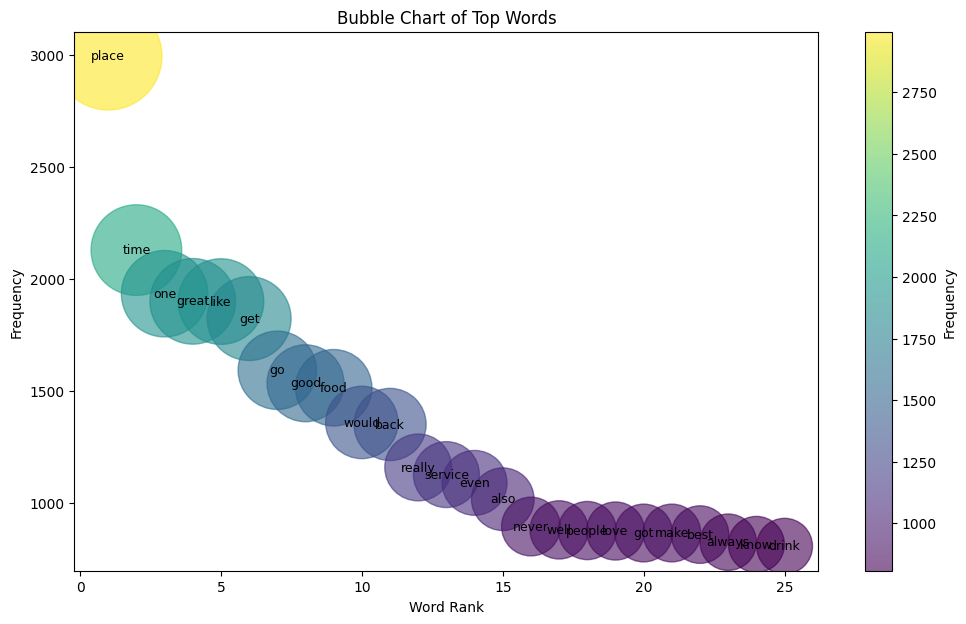

In [44]:
word_counts = np.asarray(X_bow.sum(axis=0)).ravel()
words = bow_vectorizer.get_feature_names_out()

word_freq = pd.DataFrame({
    'word': words,
    'frequency': word_counts
})

top_words = word_freq.sort_values(by='frequency', ascending=False).head(25)
top_words['rank'] = range(1, len(top_words) + 1)

plt.figure(figsize=(12, 7))
plt.scatter(
    top_words['rank'],
    top_words['frequency'],
    s=top_words['frequency'] * 2,
    alpha=0.6,
    c=top_words['frequency'],
    cmap='viridis'
)

for i, row in top_words.iterrows():
    plt.text(row['rank'], row['frequency'], row['word'], ha='center', va='center', fontsize=9)

plt.title('Bubble Chart of Top Words')
plt.xlabel('Word Rank')
plt.ylabel('Frequency')
plt.colorbar(label='Frequency')
plt.show()

/var/folders/k8/kc8jrng519q81_pvhp9qvnyr0000gn/T/ipykernel_1121/887145660.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=positive_words.values, y=positive_words.index, palette='Greens_r')
/var/folders/k8/kc8jrng519q81_pvhp9qvnyr0000gn/T/ipykernel_1121/887145660.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=negative_words.values, y=negative_words.index, palette='Reds_r')


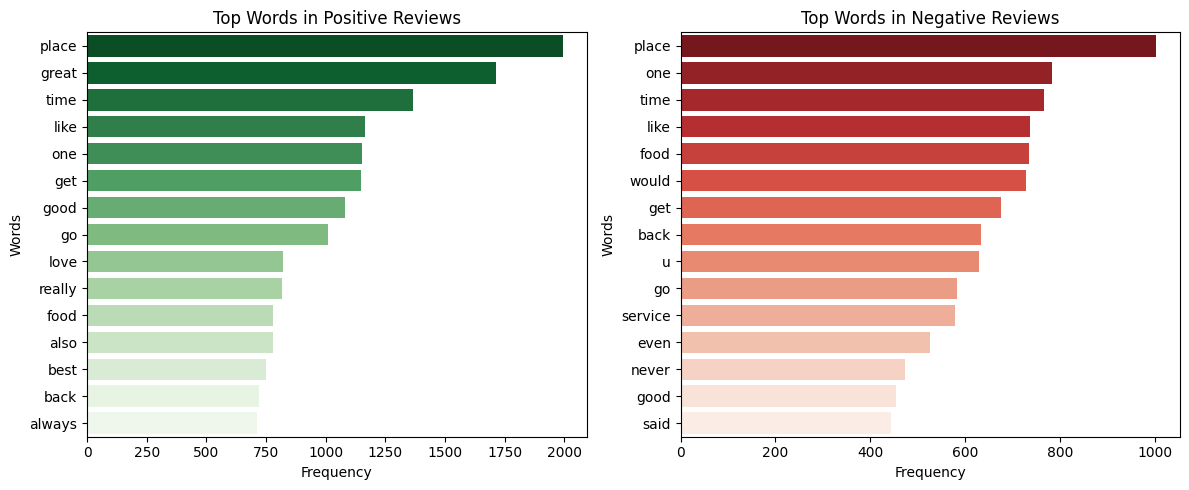

In [45]:
positive_text = ' '.join(df[df['sentiment'] == 1]['clean_review'])
negative_text = ' '.join(df[df['sentiment'] == 0]['clean_review'])

positive_words = pd.Series(positive_text.split()).value_counts().head(15)
negative_words = pd.Series(negative_text.split()).value_counts().head(15)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.barplot(x=positive_words.values, y=positive_words.index, palette='Greens_r')
plt.title('Top Words in Positive Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')

plt.subplot(1, 2, 2)
sns.barplot(x=negative_words.values, y=negative_words.index, palette='Reds_r')
plt.title('Top Words in Negative Reviews')
plt.xlabel('Frequency')
plt.ylabel('Words')

plt.tight_layout()
plt.show()